In [1]:
#!pip install -r requirements.txt

In [2]:
import os
import json
import logging
from typing import Dict, Any

import pandas as pd

import pprint

In [3]:
from src.process_function import process_transaction
from src.transaction import Transaction

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [5]:
os.environ['model_name'] = 'llama3.1'
os.environ['temperature'] = '0.5'

In [6]:
def style_plot(fig_size=(10, 6), title=None, xlabel=None, ylabel=None):
    plt.figure(figsize=fig_size)
    plt.title(title, fontsize=16, weight='bold', pad=15) if title else None
    plt.xlabel(xlabel, fontsize=12) if xlabel else None
    plt.ylabel(ylabel, fontsize=12) if ylabel else None
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    sns.despine()

In [7]:
BANK_TRANSACTIONS = os.path.join(os.path.abspath(os.path.dirname(os.path.dirname(os.path.dirname('main_app.py')))), 'data', 'bank_transactions_data_2.csv')
FRAUD_RULES = os.path.join(os.path.abspath(os.path.dirname(os.path.dirname(os.path.dirname('main_app.py')))), 'data', 'fraud_rules.json')

In [8]:
df = pd.read_csv(BANK_TRANSACTIONS)
json_rules = json.load(open(FRAUD_RULES, 'r'))

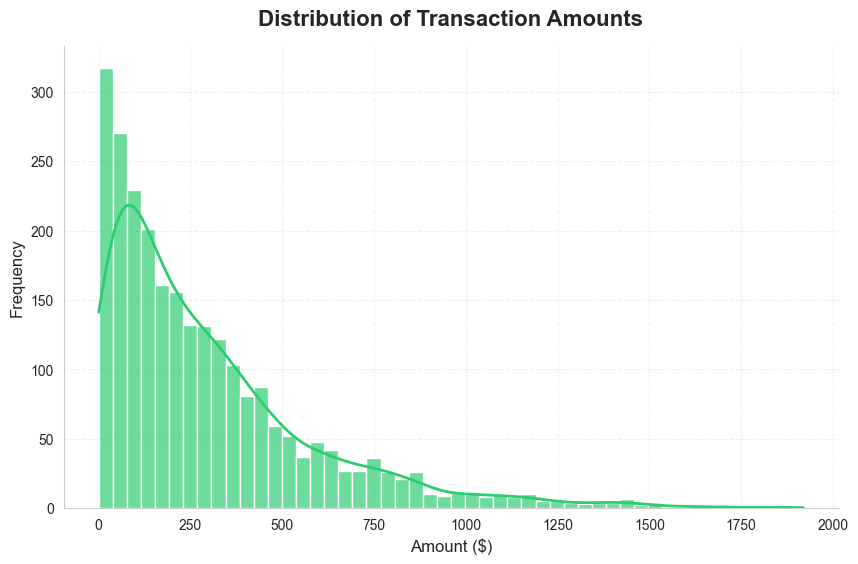

In [9]:
style_plot(title='Distribution of Transaction Amounts', xlabel='Amount ($)', ylabel='Frequency')
sns.histplot(df['TransactionAmount'], bins=50, kde=True, color='#2ecc71', 
             line_kws={'color': '#e74c3c', 'lw': 2}, alpha=0.7)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

C:\Users\rkens\AppData\Local\Temp\ipykernel_22636\1190127951.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TransactionType', y='TransactionAmount', data=df,


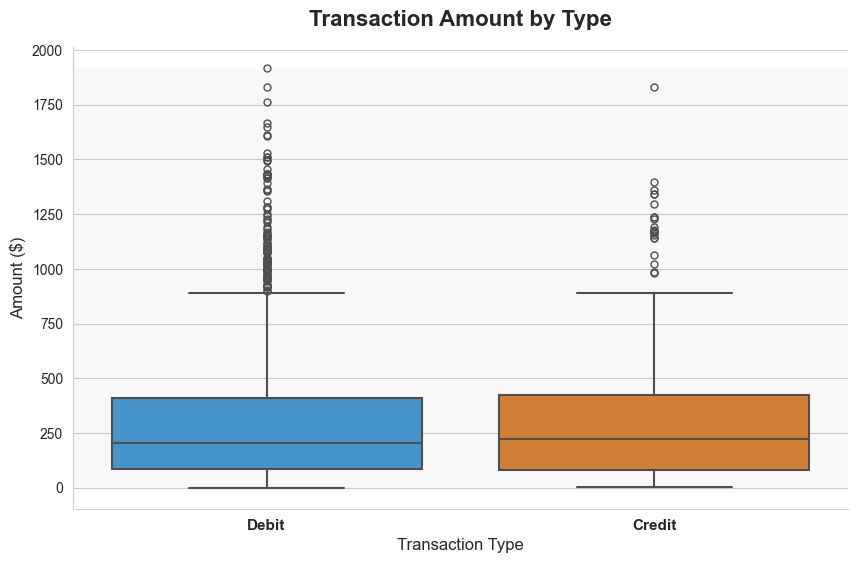

In [10]:
style_plot(title='Transaction Amount by Type', xlabel='Transaction Type', ylabel='Amount ($)')
sns.boxplot(x='TransactionType', y='TransactionAmount', data=df, 
            palette=['#3498db', '#e67e22'], linewidth=1.5, fliersize=5, saturation=0.8)
plt.xticks(fontsize=11, weight='bold')
plt.axhspan(0, df['TransactionAmount'].max(), facecolor='gray', alpha=0.05)
plt.show()

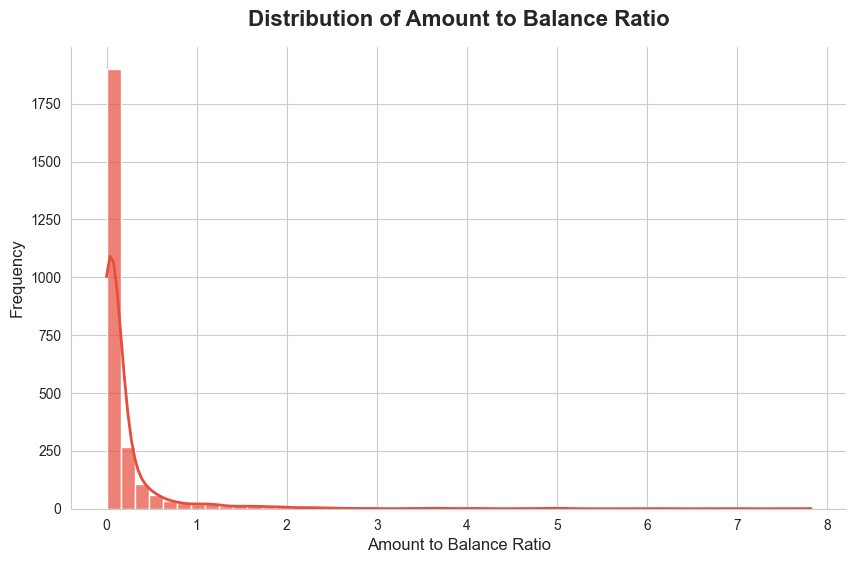

In [11]:
# Transaction Amount to Balance Ratio
df['Amount_to_Balance_Ratio'] = df['TransactionAmount'] / (df['AccountBalance'] + 1)  # Avoid division by zero
ax = style_plot(title='Distribution of Amount to Balance Ratio', 
                xlabel='Amount to Balance Ratio', ylabel='Frequency')
sns.histplot(df['Amount_to_Balance_Ratio'], bins=50, color='#e74c3c', kde=True, 
             line_kws={'color': '#2ecc71', 'lw': 2}, alpha=0.7)

plt.show()

C:\Users\rkens\AppData\Local\Temp\ipykernel_22636\2891696134.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='LoginAttempts', data=df, palette='magma')


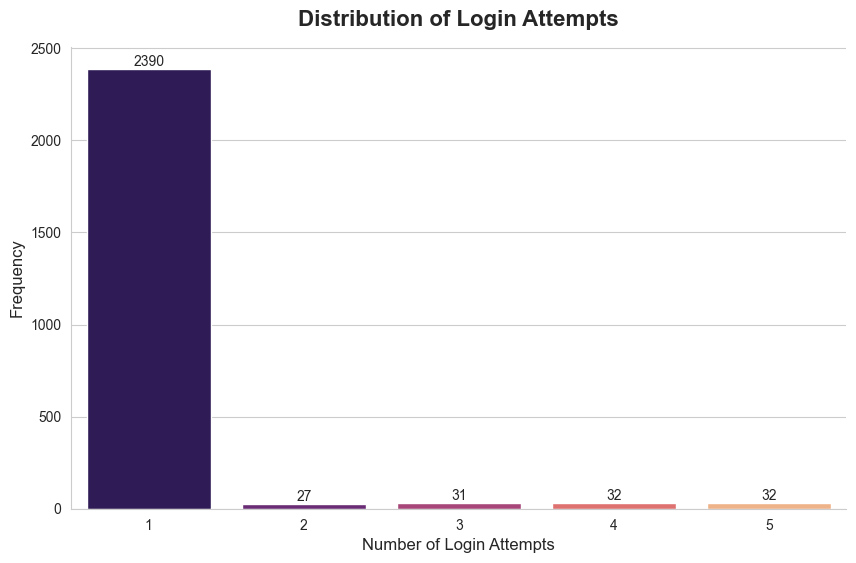

In [12]:
style_plot(title='Distribution of Login Attempts', xlabel='Number of Login Attempts', ylabel='Frequency')
sns.countplot(x='LoginAttempts', data=df, palette='magma')
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)
plt.show()

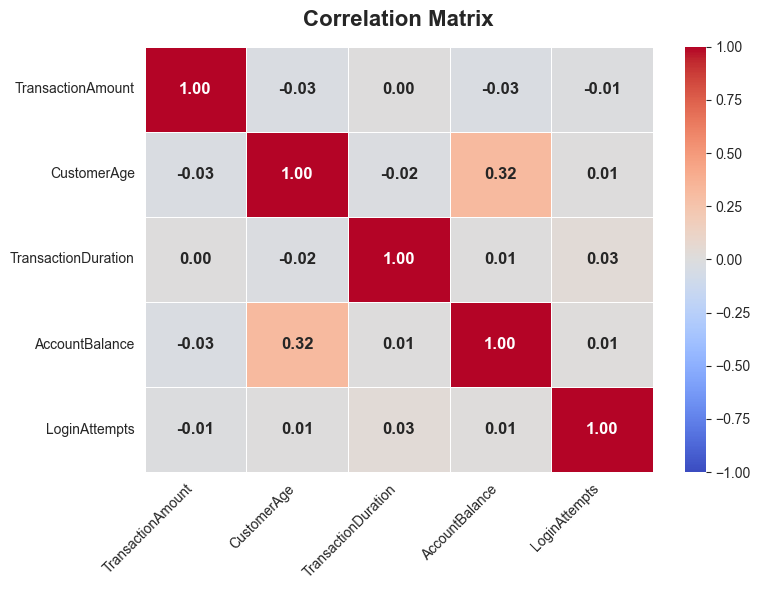

In [13]:
style_plot(fig_size=(8, 6), title='Correlation Matrix')
sns.heatmap(df[['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'AccountBalance', 'LoginAttempts']].corr(), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            fmt='.2f', annot_kws={'size': 12, 'weight': 'bold'}, linewidths=0.5, linecolor='white')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

C:\Users\rkens\AppData\Local\Temp\ipykernel_22636\2459225572.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Location', data=df, palette='viridis', order=top_locations)


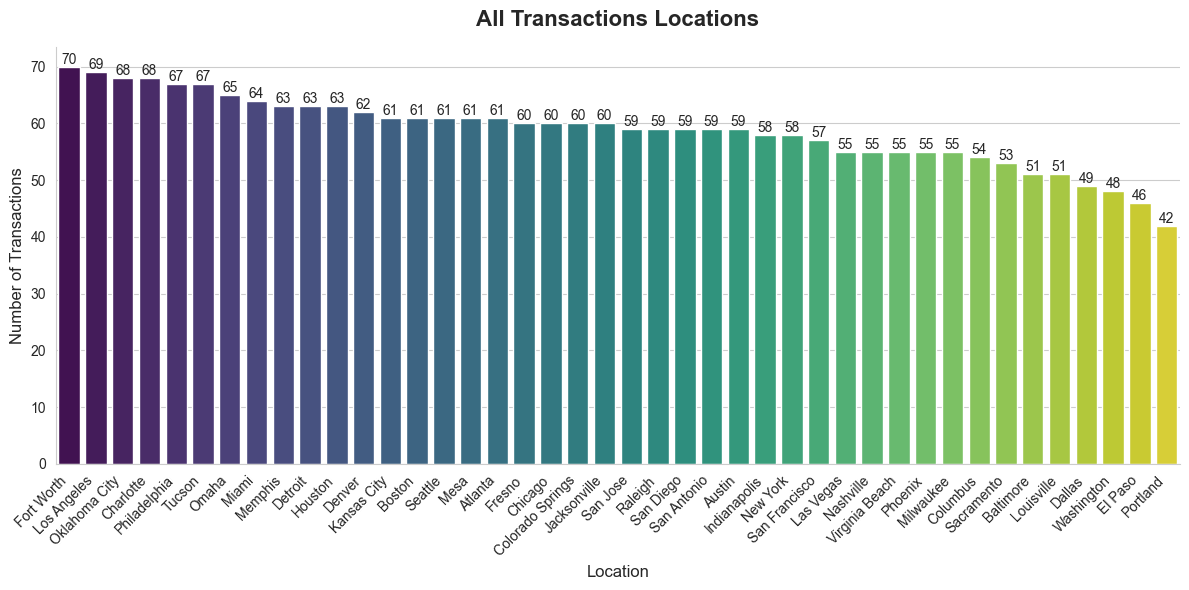

In [14]:
style_plot(fig_size=(12, 6), title='All Transactions Locations', xlabel='Location', ylabel='Number of Transactions')
top_locations = df['Location'].value_counts().index[:-1]
sns.countplot(x='Location', data=df, palette='viridis', order=top_locations)
plt.xticks(rotation=45, ha='right', fontsize=10)
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

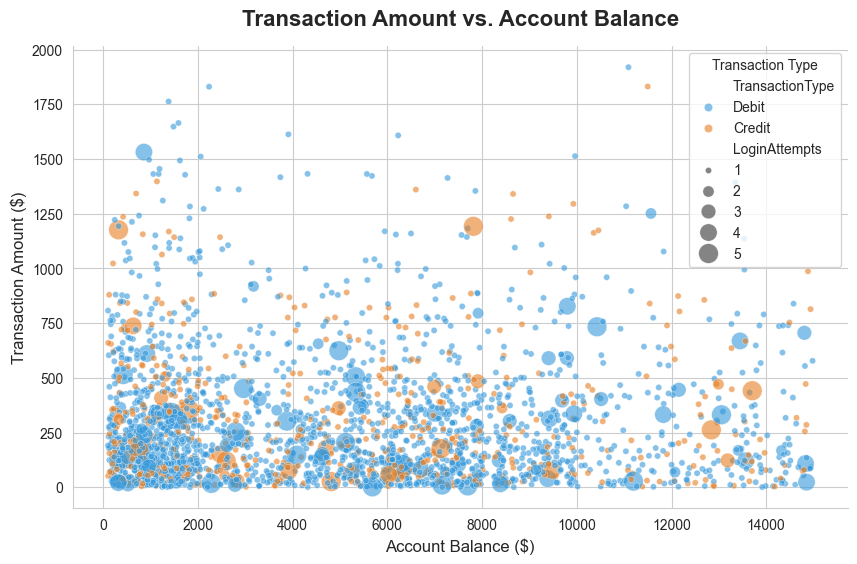

In [15]:
style_plot(fig_size=(10, 6), title='Transaction Amount vs. Account Balance', 
           xlabel='Account Balance ($)', ylabel='Transaction Amount ($)')
sns.scatterplot(x='AccountBalance', y='TransactionAmount', data=df, hue='TransactionType', 
                palette=['#3498db', '#e67e22'], size='LoginAttempts', sizes=(20, 200), alpha=0.6)
plt.legend(title='Transaction Type', fontsize=10)
plt.show()

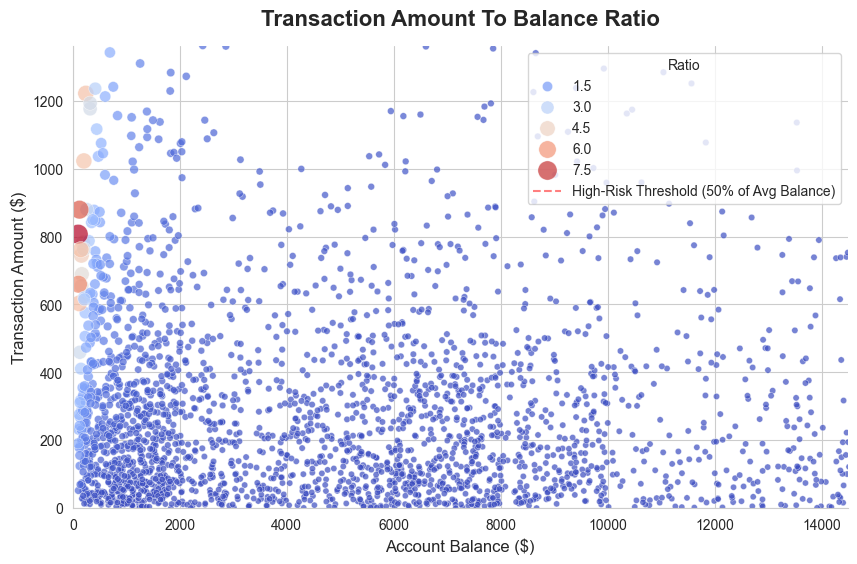

In [16]:
df['Amount_to_Balance_Ratio'] = df['TransactionAmount'] / (df['AccountBalance'] + 1e-6)
style_plot(fig_size=(10, 6), title='Transaction Amount To Balance Ratio', 
           xlabel='Account Balance ($)', 
           ylabel='Transaction Amount ($)')

# Scatter plot with color gradient based on ratio
sns.scatterplot(x='AccountBalance', y='TransactionAmount', hue='Amount_to_Balance_Ratio', 
                size='Amount_to_Balance_Ratio', sizes=(20, 200), 
                data=df, palette='coolwarm', alpha=0.7)

# Add a reference line for high-risk transactions (e.g., ratio > 0.5)
plt.axhline(y=df['AccountBalance'].mean() * 0.5, color='red', linestyle='--', alpha=0.5, 
            label='High-Risk Threshold (50% of Avg Balance)')
plt.legend(title='Ratio', fontsize=10)

# Limit axes for better visualization
plt.xlim(0, df['AccountBalance'].quantile(0.99))
plt.ylim(0, df['TransactionAmount'].quantile(0.99))

plt.show()

C:\Users\rkens\AppData\Local\Temp\ipykernel_22636\1014158934.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='LoginAttempts', y='TransactionAmount', data=df,


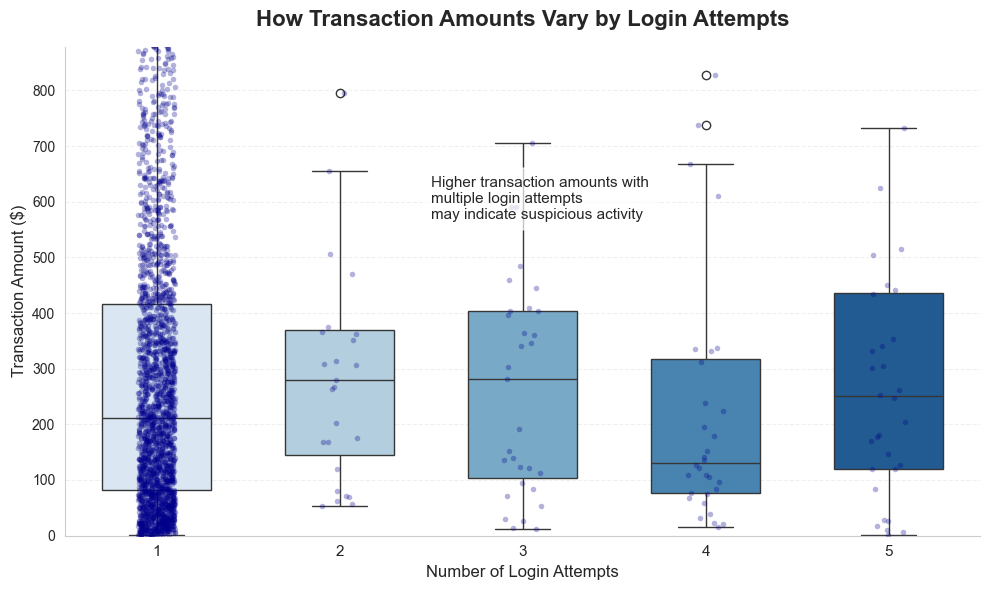

In [17]:
style_plot(title='How Transaction Amounts Vary by Login Attempts', 
           xlabel='Number of Login Attempts', 
           ylabel='Transaction Amount ($)')


sns.boxplot(x='LoginAttempts', y='TransactionAmount', data=df, 
            palette='Blues', width=0.6)

sns.stripplot(x='LoginAttempts', y='TransactionAmount', data=df,
              size=4, color='darkblue', alpha=0.3, jitter=True)


plt.xticks(fontsize=11)
plt.ylim(0, df['TransactionAmount'].quantile(0.95))  # Limit to 95th percentile for clearer visualization

# Add explanatory annotation
plt.annotate('Higher transaction amounts with\nmultiple login attempts\nmay indicate suspicious activity', 
             xy=(2, df[df['LoginAttempts'] > 1]['TransactionAmount'].median()), 
             xytext=(1.5, df['TransactionAmount'].quantile(0.85)),
             fontsize=11,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))

# Add a simple grid to help read values
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

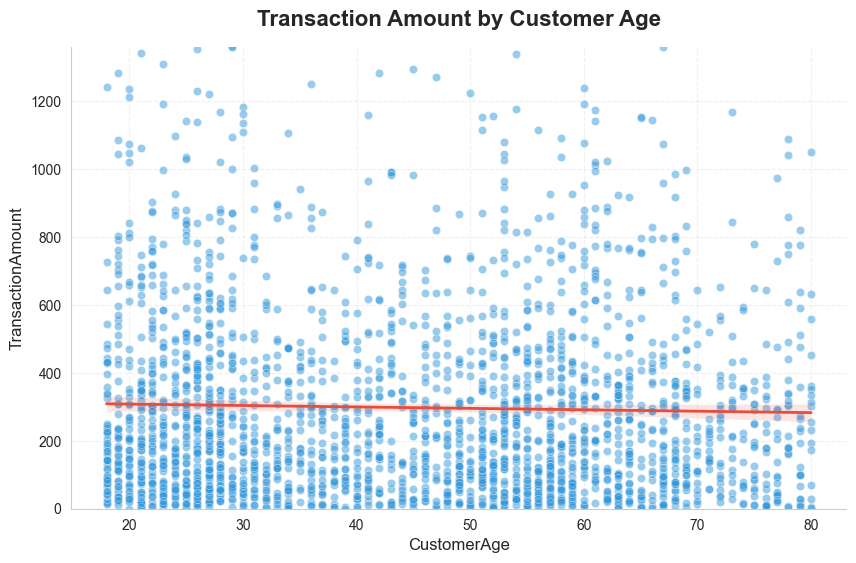

In [18]:
# Create age bins for grouping
df['AgeGroup'] = pd.cut(df['CustomerAge'], bins=[0, 18, 30, 45, 60, 100], 
                        labels=['0-18', '19-30', '31-45', '46-60', '60+'])

# Scatter plot with regression line
style_plot(fig_size=(10, 6), title='Transaction Amount by Customer Age', 
           xlabel='Customer Age', 
           ylabel='Transaction Amount ($)')

sns.scatterplot(x='CustomerAge', y='TransactionAmount', data=df, color='#3498db', alpha=0.5)
sns.regplot(x='CustomerAge', y='TransactionAmount', data=df, scatter=False, color='#e74c3c', 
            line_kws={'lw': 2})

plt.ylim(0, df['TransactionAmount'].quantile(0.99))
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

C:\Users\rkens\AppData\Local\Temp\ipykernel_22636\525619469.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AgeGroup', y='TransactionAmount', data=df, palette='Blues', linewidth=1.5, fliersize=5)


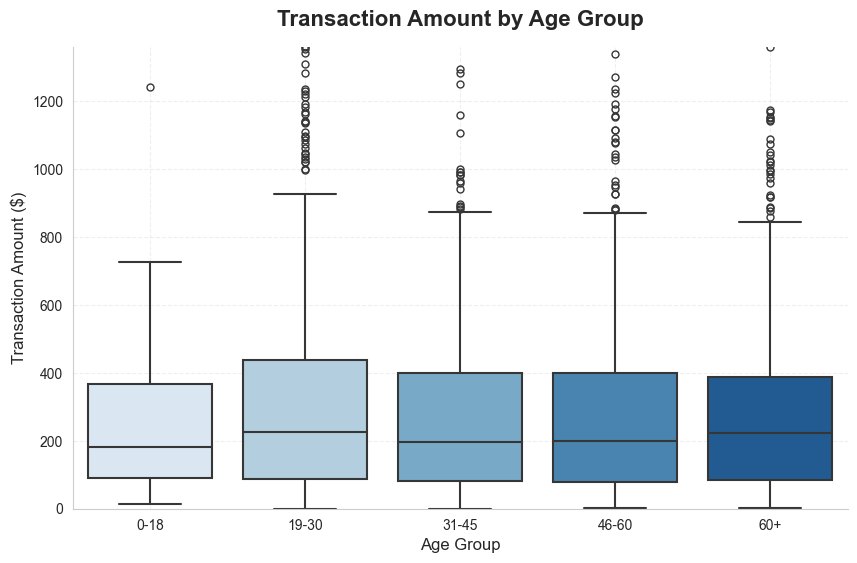

In [19]:
# Boxplot by age group
style_plot(fig_size=(10, 6), title='Transaction Amount by Age Group', 
           xlabel='Age Group', 
           ylabel='Transaction Amount ($)')

sns.boxplot(x='AgeGroup', y='TransactionAmount', data=df, palette='Blues', linewidth=1.5, fliersize=5)
plt.grid(True, linestyle='--', alpha=0.3)
plt.ylim(0, df['TransactionAmount'].quantile(0.99))
plt.show()

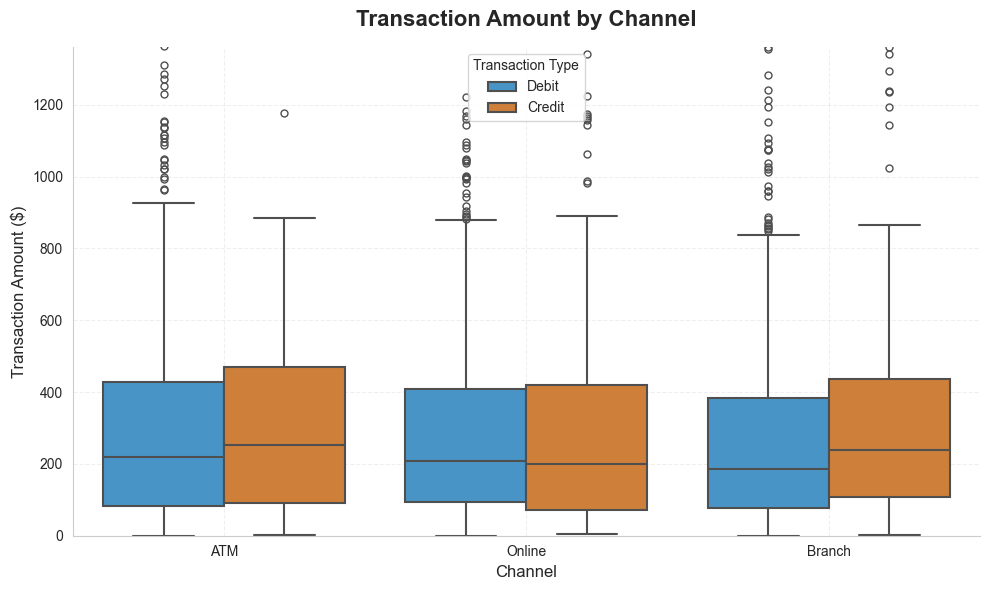

In [20]:
style_plot(fig_size=(10, 6), title='Transaction Amount by Channel', 
           xlabel='Channel', 
           ylabel='Transaction Amount ($)')

# Boxplot with hue for TransactionType
sns.boxplot(x='Channel', y='TransactionAmount', hue='TransactionType', 
            data=df, palette=['#3498db', '#e67e22'], linewidth=1.5, fliersize=5)

# Customize axes and add grid
plt.ylim(0, df['TransactionAmount'].quantile(0.99))  # Limit to 99th percentile
plt.legend(title='Transaction Type', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\rkens\AppData\Local\Temp\ipykernel_22636\2347307343.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TransactionType', data=df, palette=['#3498db', '#e67e22'])


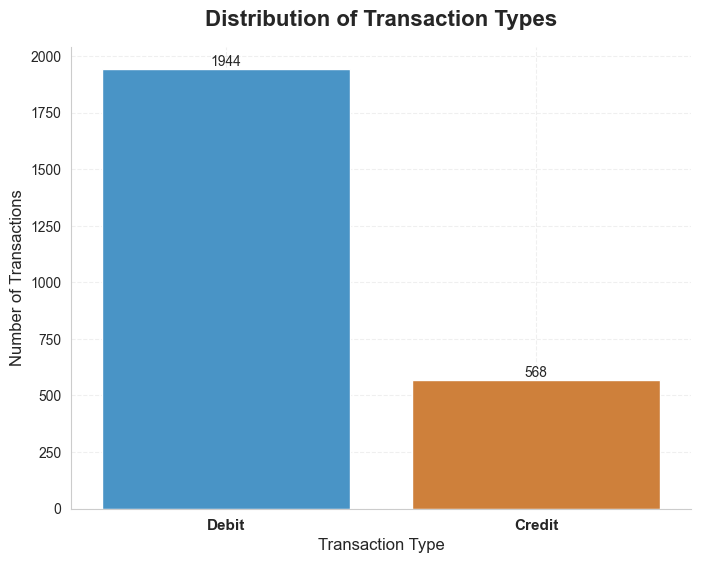

In [21]:
# Count plot for TransactionType
style_plot(fig_size=(8, 6), title='Distribution of Transaction Types', 
           xlabel='Transaction Type', 
           ylabel='Number of Transactions')

# Plot with custom styling
sns.countplot(x='TransactionType', data=df, palette=['#3498db', '#e67e22'])

# Add value labels on top of bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)

plt.xticks(fontsize=11, weight='bold')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

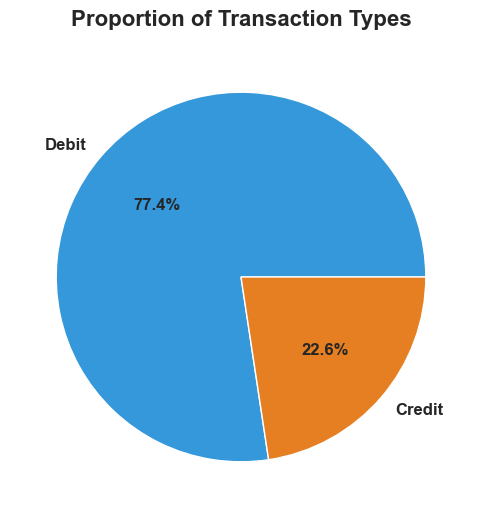

In [22]:
# Pie chart for proportions
plt.figure(figsize=(6, 6))
df['TransactionType'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#3498db', '#e67e22'], 
                                              textprops={'fontsize': 12, 'weight': 'bold'})
plt.title('Proportion of Transaction Types', fontsize=16, weight='bold', pad=15)
plt.ylabel('')  # Remove y-label for pie chart
plt.show()

C:\Users\rkens\AppData\Local\Temp\ipykernel_22636\2626346803.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MerchantID', y='TransactionCount', data=top_merchants, palette='Set2')


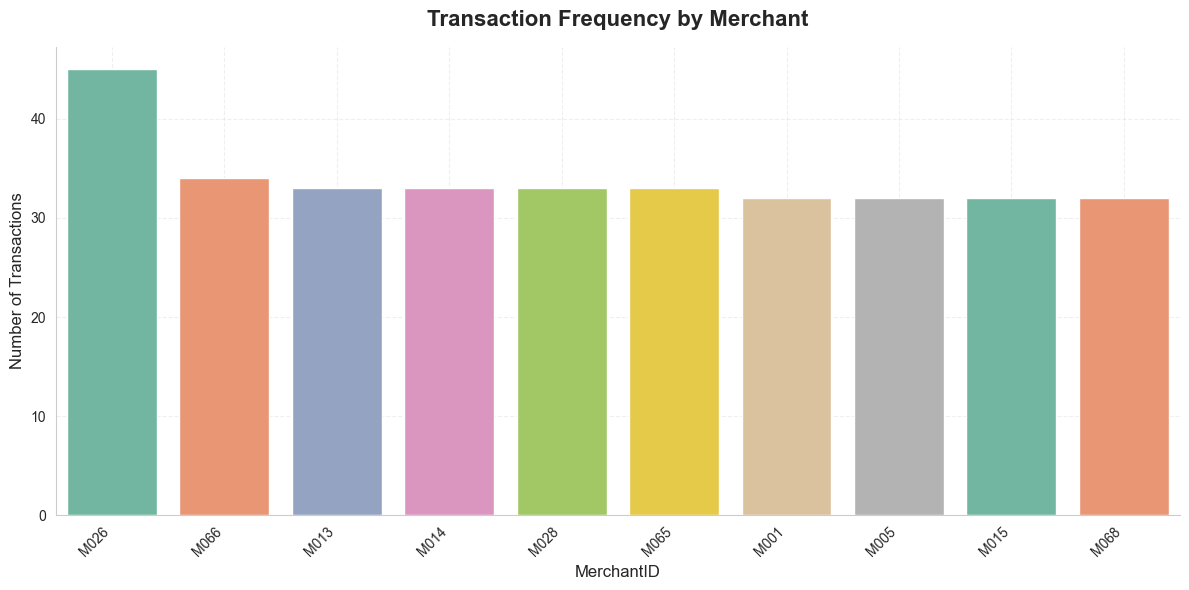

In [23]:
# Aggregate data by MerchantID
merchant_usage = df.groupby('MerchantID').agg({
    'TransactionID': 'count',  # Number of transactions per merchant
    'TransactionAmount': 'mean'  # Average transaction amount per merchant
}).reset_index().rename(columns={'TransactionID': 'TransactionCount'})

# Bar plot for transaction count per MerchantID
style_plot(fig_size=(12, 6), title='Transaction Frequency by Merchant', 
           xlabel='MerchantID', 
           ylabel='Number of Transactions')

# Plot top 10 merchants by transaction count
top_merchants = merchant_usage.nlargest(10, 'TransactionCount')
sns.barplot(x='MerchantID', y='TransactionCount', data=top_merchants, palette='Set2')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\rkens\AppData\Local\Temp\ipykernel_22636\2958650747.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='MerchantID', y='TransactionAmount',


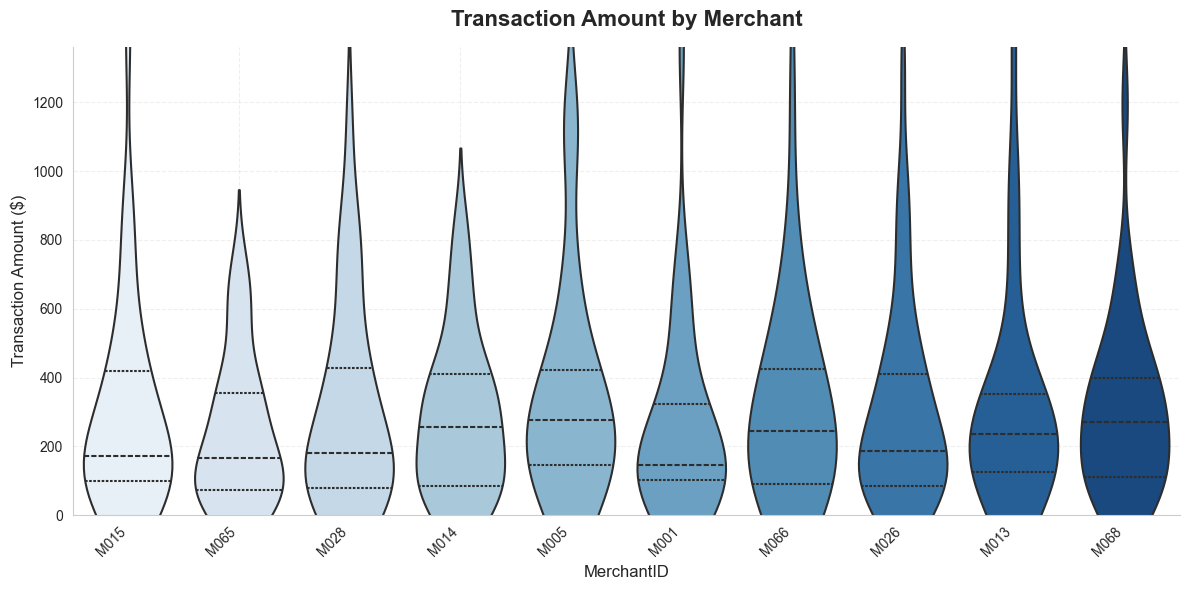

In [24]:
# Violin plot for transaction amount by MerchantID
style_plot(fig_size=(12, 6), title='Transaction Amount by Merchant', 
           xlabel='MerchantID', 
           ylabel='Transaction Amount ($)')

sns.violinplot(x='MerchantID', y='TransactionAmount', 
               data=df[df['MerchantID'].isin(top_merchants['MerchantID'])], 
               palette='Blues', inner='quartile', linewidth=1.5)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylim(0, df['TransactionAmount'].quantile(0.99))
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
processed_transactions = []
output_filename = "processed_transactions_results.jsonl"

In [31]:
print(f"Iniciando procesamiento de {len(df)} transacciones...")
for i, transaction_data in enumerate(df.to_dict(orient='records')):
    print(f"Procesando transacción {i+1}/{len(df)}: ID {transaction_data.get('TransactionID')}")
    try:
        result = process_transaction(transaction_data=transaction_data, fraud_rules=json_rules)
        processed_transactions.append(result)

        with open(output_filename, 'a', encoding='utf-8') as f:
            json.dump(result, f, ensure_ascii=False)
            f.write('\n')

    except Exception as e:
        print(f"Error al procesar transacción {transaction_data.get('TransactionID')}: {e}")
        processed_transactions.append({**transaction_data, 'error': str(e)})
    if i % 10 == 0:
        print(f"Progreso: {i+1}/{len(df)} transacciones procesadas.")
    # Terminar el bucle si se alcanza un número específico de transacciones
    # cuando i sea 100 terminar el bucle
    if i >= 1000:
        print("Procesamiento interrumpido después de 100 transacciones.")
        break
        

print(f"Procesamiento completado. Resultados guardados en {output_filename}.")

Iniciando procesamiento de 2512 transacciones...
Procesando transacción 1/2512: ID TX000001
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Progreso: 1/2512 transacciones procesadas.
Procesando transacción 2/2512: ID TX000002
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 3/2512: ID TX000003
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 4/2512: ID TX000004
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dime

🚨 ¡ATENCIÓN! Transacción Potencialmente Fraudulenta: TX000014 🚨
Monto: $781.76, Comercio: M025, Ubicación: Memphis


Procesando transacción 15/2512: ID TX000015
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 16/2512: ID TX000016
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 17/2512: ID TX000017
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 18/2512: ID TX000018
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 19/2512: ID TX000019
EmbeddingManager: Intentando ver

🚨 ¡ATENCIÓN! Transacción Potencialmente Fraudulenta: TX000034 🚨
Monto: $877.81, Comercio: M094, Ubicación: Los Angeles


Procesando transacción 35/2512: ID TX000035
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 36/2512: ID TX000036
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 37/2512: ID TX000037
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 38/2512: ID TX000038
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 39/2512: ID TX000039
EmbeddingManager: Intentando ver

...

Procesando transacción 900/2512: ID TX000900
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 901/2512: ID TX000901
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Progreso: 901/2512 transacciones procesadas.
Procesando transacción 902/2512: ID TX000902
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 903/2512: ID TX000903
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 904/

🚨 ¡ATENCIÓN! Transacción Potencialmente Fraudulenta: TX000935 🚨
Monto: $1022.75, Comercio: M091, Ubicación: San Jose


Procesando transacción 936/2512: ID TX000936
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 937/2512: ID TX000937
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 938/2512: ID TX000938
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 939/2512: ID TX000939
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 940/2512: ID TX000940
EmbeddingManager: Intentand

🚨 ¡ATENCIÓN! Transacción Potencialmente Fraudulenta: TX000952 🚨
Monto: $492.84, Comercio: M081, Ubicación: Indianapolis


Procesando transacción 953/2512: ID TX000953
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 954/2512: ID TX000954
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 955/2512: ID TX000955
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 956/2512: ID TX000956
EmbeddingManager: Intentando verificar la disponibilidad del modelo 'llama3.1' en Ollama...
EmbeddingManager: Modelo 'llama3.1' disponible y respondió con un embedding de dimensión 4096.
Procesando transacción 957/2512: ID TX000957
EmbeddingManager: Intentand